In [ ]:
# Cell 1
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.ticker as mticker

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import RandomOverSampler

In [ ]:
# Cell 2
seed = 10
# Number of repeated model training
n_repeats = 200  
# Number of top features to display
top_n = 10  

os.makedirs("results", exist_ok=True)
os.makedirs("Pictures", exist_ok=True)

In [ ]:
# Cell 3
# Best XGBoost parameters obtained from previous tuning
best_xgb_params = {
    "mask_before": {
        "colsample_bytree": 0.6,
        "gamma": 0.1,
        "learning_rate": 0.05,
        "max_depth": 7,
        "min_child_weight": 1,
        "reg_lambda": 1.0,
        "subsample": 0.8
    },
    "mask_after": {
        "colsample_bytree": 0.6,
        "gamma": 1.0,
        "learning_rate": 0.05,
        "max_depth": 7,
        "min_child_weight": 5,
        "reg_lambda": 1.0,
        "subsample": 0.8
    },
    "general_before": {
        "colsample_bytree": 0.6,
        "gamma": 1.0,
        "learning_rate": 0.05,
        "max_depth": 7,
        "min_child_weight": 1,
        "reg_lambda": 1.0,
        "subsample": 0.8
    },
    "general_after": {
        "colsample_bytree": 0.6,
        "gamma": 1.0,
        "learning_rate": 0.05,
        "max_depth": 7,
        "min_child_weight": 5,
        "reg_lambda": 1.0,
        "subsample": 0.8
    }
}

# Best Random Forest parameters obtained from previous tuning
best_rf_params = {
    "mask_before": {
        "criterion": "entropy",
        "max_depth": 20,
        "max_features": "sqrt",
        "min_samples_leaf": 1,
        "min_samples_split": 2
    },
    "mask_after": {
        "criterion": "entropy",
        "max_depth": 20,
        "max_features": "sqrt",
        "min_samples_leaf": 1,
        "min_samples_split": 2
    },
    "general_before": {
        "criterion": "entropy",
        "max_depth": 20,
        "max_features": "log2",
        "min_samples_leaf": 1,
        "min_samples_split": 2
    },
    "general_after": {
        "criterion": "entropy",
        "max_depth": 20,
        "max_features": "sqrt",
        "min_samples_leaf": 1,
        "min_samples_split": 2
    }
}

In [ ]:
# Cell 4
# Load training dataset for a given task
def load_train(prefix):
    X_train = pd.read_csv(f"data/{prefix}_X_train.csv", keep_default_na=False)
    y_train = pd.read_csv(f"data/{prefix}_y_train.csv", keep_default_na=False).values.ravel()
    return X_train, y_train

# Prepare feature matrix (convert types + dummy encoding)
def prepare_X(X):
    X = X.copy()

    # Convert boolean columns to integers
    bool_cols = X.select_dtypes(include=["bool"]).columns
    if len(bool_cols) > 0:
        X[bool_cols] = X[bool_cols].astype(int)

    # One-hot encoding for categorical variables
    X = pd.get_dummies(X, drop_first=False)
    return X

In [ ]:
# Cell 5
# Collect feature importance through repeated model training
def collect_feature_importance(prefix, model_type, params, n_repeats=200):
    X_train, y_train = load_train(prefix)

    # Prepare features
    X_train = prepare_X(X_train)
    feature_names = X_train.columns.tolist()

    importance_records = []

    # Repeat training multiple times to estimate stability
    for i in range(n_repeats):
        upsampler = RandomOverSampler(random_state=seed + i) # Apply oversampling to balance classes
        X_up, y_up = upsampler.fit_resample(X_train, y_train)

        # Select model type
        if model_type == "xgb":
            model = XGBClassifier(
                n_estimators=250,
                objective="binary:logistic",
                eval_metric="auc",
                random_state=seed + i,
                tree_method="hist",
                **params
            )
        elif model_type == "rf":
            model = RandomForestClassifier(
                n_estimators=250,
                bootstrap=True,
                random_state=seed + i,
                n_jobs=-1,
                **params
            )
        else:
            raise ValueError("model_type must be 'xgb' or 'rf'")
        
        # Train model
        model.fit(X_up, y_up)

        # Extract feature importance scores
        importances = model.feature_importances_

        # Store importance for this iteration
        fold_df = pd.DataFrame({
            "feature": feature_names,
            "importance": importances,
            "repeat": i + 1
        })

        importance_records.append(fold_df)
    
    # Combine all repeats into a single DataFrame
    importance_df = pd.concat(importance_records, ignore_index=True)
    return importance_df

In [ ]:
# Cell 6
# Summarise feature importance using median and interquartile range
def summarize_importance(importance_df, top_n=10):

    # Compute median, 25th percentile (q1), and 75th percentile (q3)
    summary = importance_df.groupby("feature")["importance"].agg(
        median_importance="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    ).reset_index()

    # Calculate variability (IQR)
    summary["iqr"] = summary["q3"] - summary["q1"]

    # Rank features by median importance
    summary = summary.sort_values(
        by="median_importance",
        ascending=False
    ).reset_index(drop=True)

    # Return top N features
    return summary.head(top_n)

In [ ]:
# Cell 7
# Remove location-related features (state variables not used for interpretation)
def remove_state_features(importance_df):
    return importance_df[
        ~importance_df["feature"].str.contains("state_", case=False, na=False)
    ].copy()

In [ ]:
# Cell 8
# Run feature importance extraction
# XGBoost
imp_xgb_mask_before = collect_feature_importance("mask_before", "xgb", best_xgb_params["mask_before"], n_repeats=n_repeats)
imp_xgb_mask_after = collect_feature_importance("mask_after", "xgb", best_xgb_params["mask_after"], n_repeats=n_repeats)
imp_xgb_general_before = collect_feature_importance("general_before", "xgb", best_xgb_params["general_before"], n_repeats=n_repeats)
imp_xgb_general_after = collect_feature_importance("general_after", "xgb", best_xgb_params["general_after"], n_repeats=n_repeats)

# Random Forest
imp_rf_mask_before = collect_feature_importance("mask_before", "rf", best_rf_params["mask_before"], n_repeats=n_repeats)
imp_rf_mask_after = collect_feature_importance("mask_after", "rf", best_rf_params["mask_after"], n_repeats=n_repeats)
imp_rf_general_before = collect_feature_importance("general_before", "rf", best_rf_params["general_before"], n_repeats=n_repeats)
imp_rf_general_after = collect_feature_importance("general_after", "rf", best_rf_params["general_after"], n_repeats=n_repeats)

In [ ]:
# Cell 9
# Extract top features
# Select top N features after removing state variables
top_xgb_mask_before = summarize_importance(remove_state_features(imp_xgb_mask_before), top_n=top_n)
top_xgb_mask_after = summarize_importance(remove_state_features(imp_xgb_mask_after), top_n=top_n)
top_xgb_general_before = summarize_importance(remove_state_features(imp_xgb_general_before), top_n=top_n)
top_xgb_general_after = summarize_importance(remove_state_features(imp_xgb_general_after), top_n=top_n)

top_rf_mask_before = summarize_importance(remove_state_features(imp_rf_mask_before), top_n=top_n)
top_rf_mask_after = summarize_importance(remove_state_features(imp_rf_mask_after), top_n=top_n)
top_rf_general_before = summarize_importance(remove_state_features(imp_rf_general_before), top_n=top_n)
top_rf_general_after = summarize_importance(remove_state_features(imp_rf_general_after), top_n=top_n)

In [ ]:
# Cell 10
# Save results to CSV
# Save top features for each model and dataset
top_xgb_mask_before.to_csv("results/top_xgb_mask_before.csv", index=False)
top_xgb_mask_after.to_csv("results/top_xgb_mask_after.csv", index=False)
top_xgb_general_before.to_csv("results/top_xgb_general_before.csv", index=False)
top_xgb_general_after.to_csv("results/top_xgb_general_after.csv", index=False)

top_rf_mask_before.to_csv("results/top_rf_mask_before.csv", index=False)
top_rf_mask_after.to_csv("results/top_rf_mask_after.csv", index=False)
top_rf_general_before.to_csv("results/top_rf_general_before.csv", index=False)
top_rf_general_after.to_csv("results/top_rf_general_after.csv", index=False)

In [ ]:
# Cell 11
# Plot simple before vs after comparison
def plot_before_after(top_before, top_after, title, output_path):

    # Create two subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 12), sharex=True)

    # Sort features for better visual alignment
    before_plot = top_before.sort_values("median_importance", ascending=True)
    after_plot = top_after.sort_values("median_importance", ascending=True)

    # Before mandates plot
    axes[0].barh(
        before_plot["feature"],
        before_plot["median_importance"],
        xerr=[before_plot["median_importance"] - before_plot["q1"],
              before_plot["q3"] - before_plot["median_importance"]],
        capsize=3
    )
    axes[0].set_title("Before mandates")
    axes[0].set_xlabel("Median feature importance")

    # After mandates plot
    axes[1].barh(
        after_plot["feature"],
        after_plot["median_importance"],
        xerr=[after_plot["median_importance"] - after_plot["q1"],
              after_plot["q3"] - after_plot["median_importance"]],
        capsize=3
    )
    axes[1].set_title("After mandates")
    axes[1].set_xlabel("Median feature importance")

    # Overall figure title
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

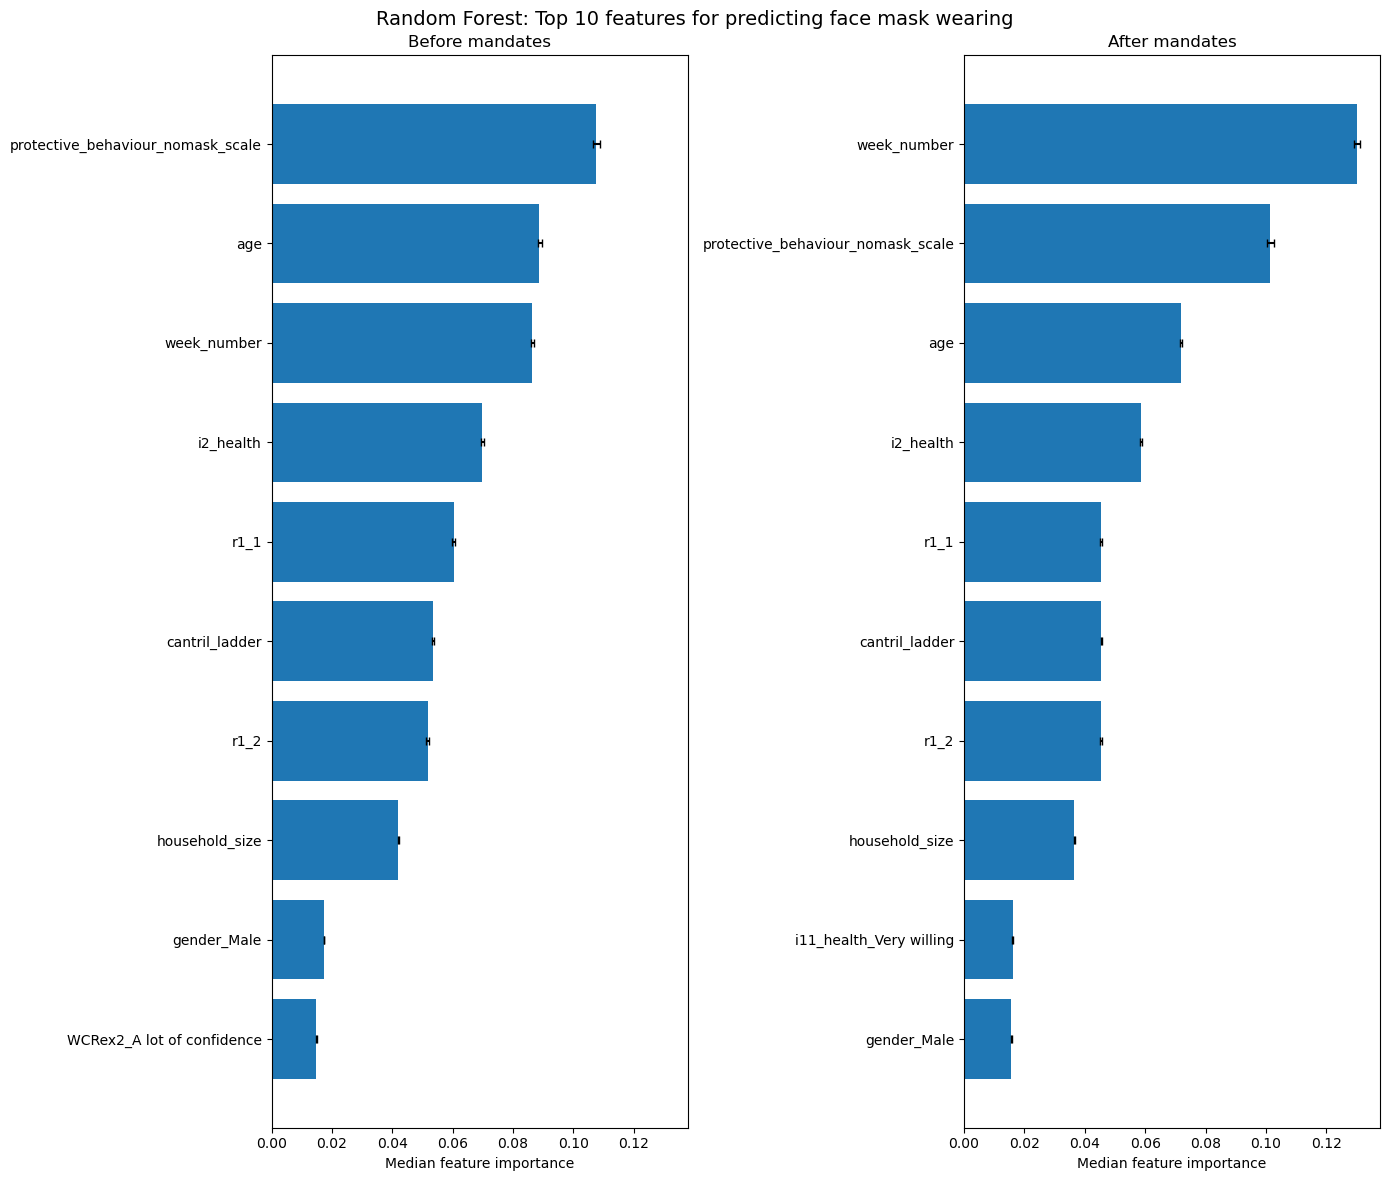

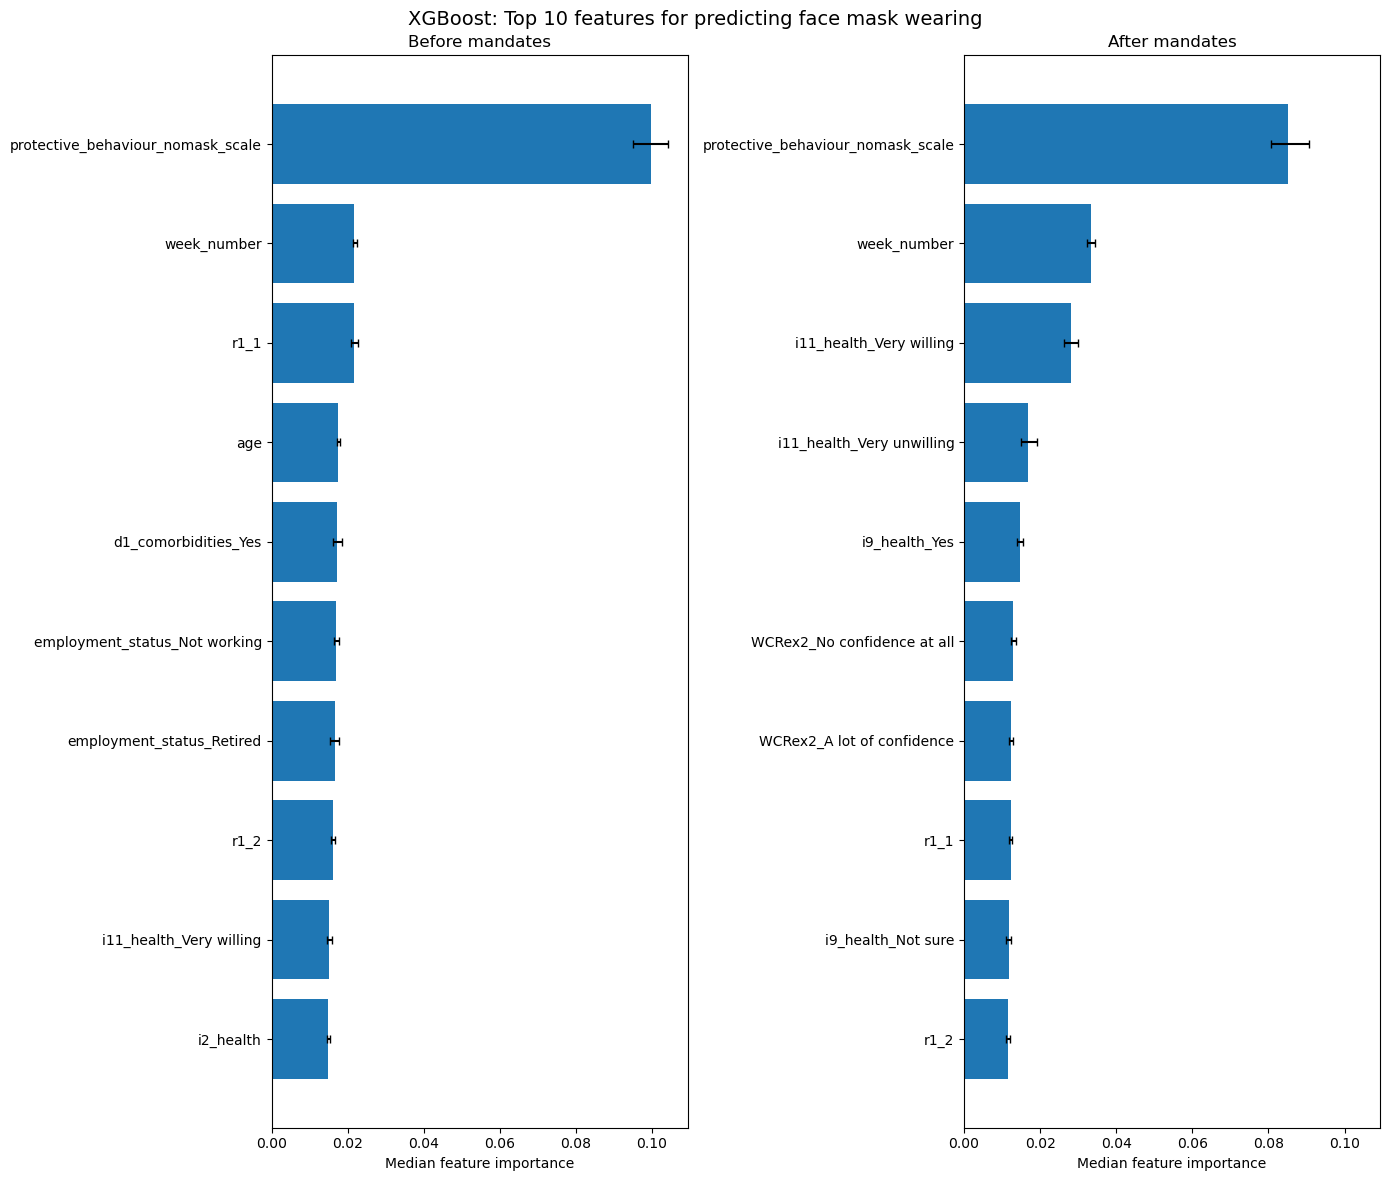

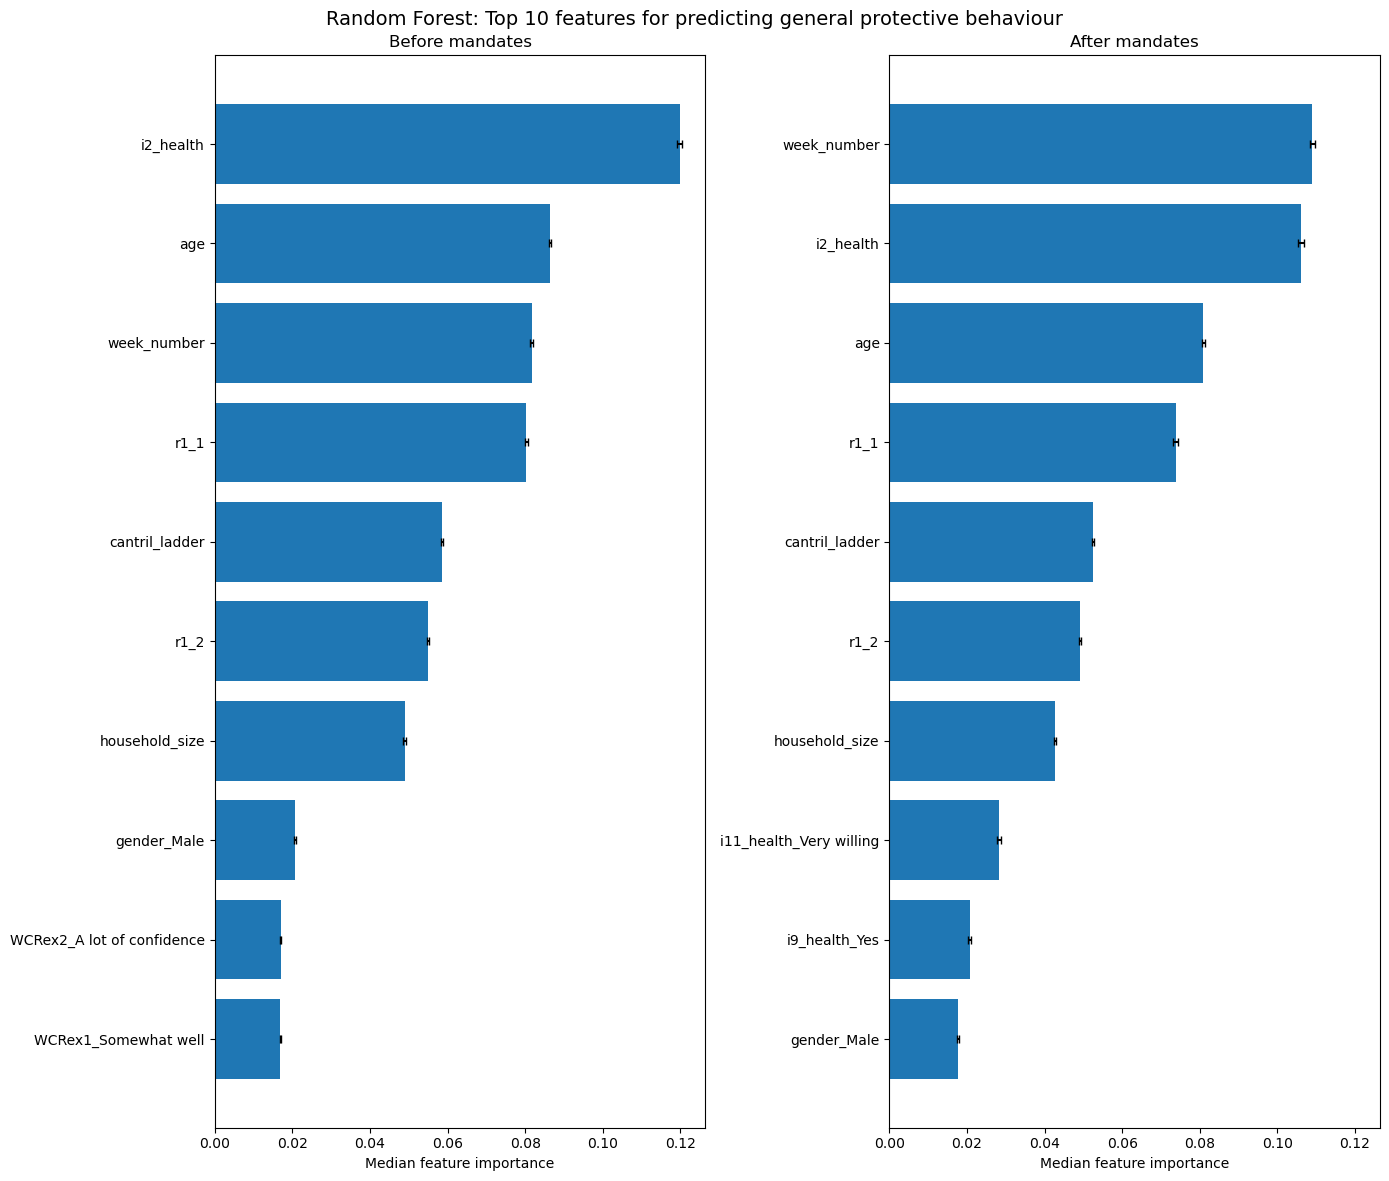

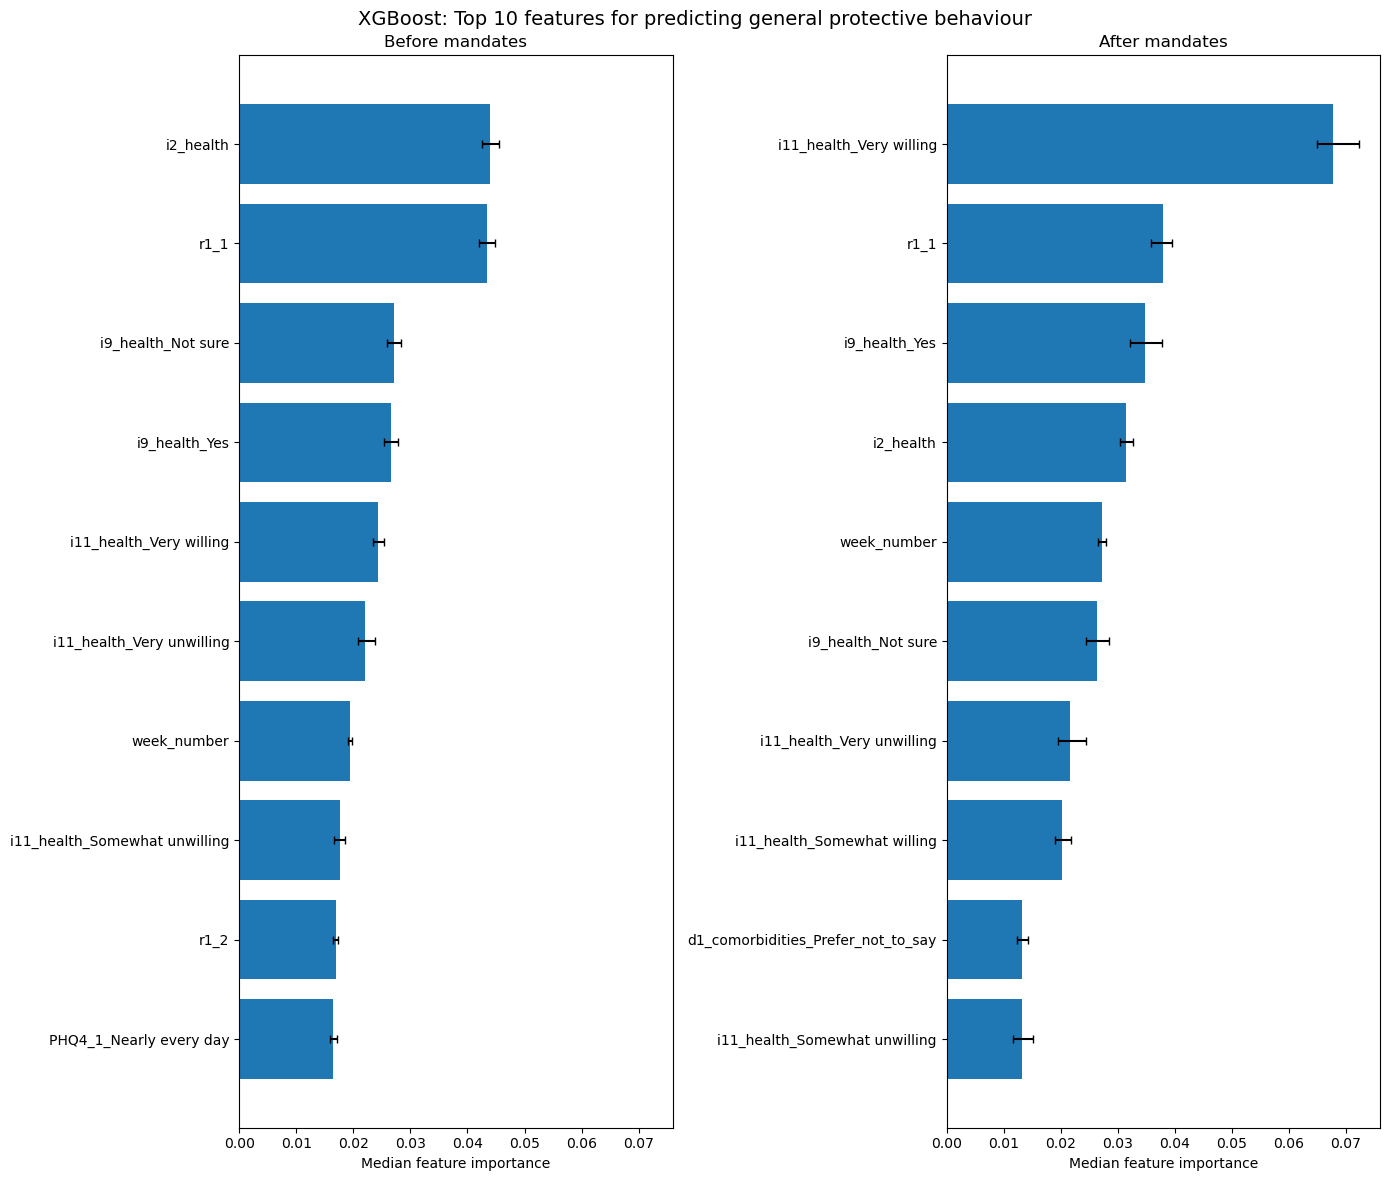

In [ ]:
# Cell 12
plot_before_after(
    top_rf_mask_before,
    top_rf_mask_after,
    "Random Forest: Top 10 features for predicting face mask wearing",
    "Pictures/rf_mask_wearing_importance.png"
)

plot_before_after(
    top_xgb_mask_before,
    top_xgb_mask_after,
    "XGBoost: Top 10 features for predicting face mask wearing",
    "Pictures/xgb_mask_wearing_importance.png"
)

plot_before_after(
    top_rf_general_before,
    top_rf_general_after,
    "Random Forest: Top 10 features for predicting general protective behaviour",
    "Pictures/rf_general_behaviour_importance.png"
)

plot_before_after(
    top_xgb_general_before,
    top_xgb_general_after,
    "XGBoost: Top 10 features for predicting general protective behaviour",
    "Pictures/xgb_general_behaviour_importance.png"
)

In [ ]:
# Cell 13
name_map_df = pd.read_excel("change.xlsx")

rename_map = dict(zip(name_map_df["Original"], name_map_df["New"]))

In [ ]:
# Cell 14
category_map = {
    # Self-protective behaviours
    "Protective Behaviour": "Self-protective behaviours",
    "Very Willing To Isolate": "Self-protective behaviours",
    "Somewhat Willing To Isolate": "Self-protective behaviours",
    "Very Unwilling To Isolate": "Self-protective behaviours",
    "Somewhat Unwilling To Isolate": "Self-protective behaviours",
    "Isolate If Unwell(Yes)": "Self-protective behaviours",
    "Isolate If Unwell(Not Sure)": "Self-protective behaviours",
    "Non-Household Contact": "Self-protective behaviours",

    # Demographics
    "Age": "Demographics",
    "Household Size": "Demographics",
    "gender_Male": "Demographics",
    "Employment Status(Retired)": "Demographics",
    "Employment Status(Not working)": "Demographics",

    # Health, mental health and wellbeing
    "Cantril Ladder": "Health, mental health and wellbeing",
    "Little interest or pleasure": "Health, mental health and wellbeing",
    "Worrying(Yes)": "Health, mental health and wellbeing",
    "Worrying(Prefer Not To Say)": "Health, mental health and wellbeing",

    # Perception of illness threat
    "Perceived Severity": "Perception of illness threat",
    "Perceived Suspectibility": "Perception of illness threat",

    # Time
    "Week Number": "Time",

    # Trust in government
    "Confidence in response(A Lot Of Confidence)": "Trust in government",
    "Confidence in response(No Confidence At All)": "Trust in government",
    "Satisfaction With The Government": "Trust in government"
}

In [ ]:
# Cell 15
category_colors = {
    "Self-protective behaviours": "#0B6FA4",
    "Demographics": "#2E8BC0",
    "Health, mental health and wellbeing": "#6BAED6",
    "Perception of illness threat": "#B8AF9D",
    "Time": "#D98B36",
    "Trust in government": "#C76E00"
}

In [ ]:
# Cell 16
def apply_readable_labels_and_categories(mirror_df, rename_map, category_map, category_colors):
    df = mirror_df.copy()

    df["readable_feature"] = df["feature"].map(rename_map).fillna(df["feature"])

    df["category"] = df["readable_feature"].map(category_map).fillna("Unclassified")

    df["color"] = df["category"].map(category_colors).fillna("#999999")

    return df

In [ ]:
# Cell 17
# Build mirrored comparison
def build_mirrored_top10_table(imp_before, imp_after, top_n=10):
    # Summarise full importance results
    before_full = summarize_importance(remove_state_features(imp_before), top_n=1000)
    after_full = summarize_importance(remove_state_features(imp_after), top_n=1000)
    
    # Select top N features separately for before and after
    before_top = before_full.head(top_n).copy()
    after_top = after_full.head(top_n).copy()

    # Combine feature sets
    feature_union = sorted(set(before_top["feature"]) | set(after_top["feature"]))

    rows = []
    for feat in feature_union:
        row = {"feature": feat}

        # Fill values for before mandates period
        if feat in set(before_top["feature"]):
            b = before_top[before_top["feature"] == feat].iloc[0]
            row["median_importance_before"] = b["median_importance"]
            row["q1_before"] = b["q1"]
            row["q3_before"] = b["q3"]
        else:
            # If feature not in top list, assign zero
            row["median_importance_before"] = 0.0
            row["q1_before"] = 0.0
            row["q3_before"] = 0.0

        # Fill values for after mandates period
        if feat in set(after_top["feature"]):
            a = after_top[after_top["feature"] == feat].iloc[0]
            row["median_importance_after"] = a["median_importance"]
            row["q1_after"] = a["q1"]
            row["q3_after"] = a["q3"]
        else:
            row["median_importance_after"] = 0.0
            row["q1_after"] = 0.0
            row["q3_after"] = 0.0

        # Used for sorting
        row["max_importance"] = max(
            row["median_importance_before"],
            row["median_importance_after"]
        )

        rows.append(row)

    
    merged = pd.DataFrame(rows)

    # Sort for plotting
    merged = merged.sort_values("max_importance", ascending=True).reset_index(drop=True)

    return merged

In [ ]:
# Cell 18
# Plot mirrored feature importance comparison before and after mandates
def plot_mirrored_before_after_colored(df, title=None, output_path=None, show_legend=True):
    fig, ax = plt.subplots(figsize=(16, 10))

    # Set y-axis positions for each feature
    y = np.arange(len(df))

    # Before values are shown on the left side, so they are converted to negative values
    before_vals = -df["median_importance_before"].values
    after_vals = df["median_importance_after"].values

    # Error bars for before period, based on Q1 and Q3
    before_err_left = (df["q3_before"] - df["median_importance_before"]).values
    before_err_right = (df["median_importance_before"] - df["q1_before"]).values

    # Error bars for after period, based on Q1 and Q3
    after_err_left = (df["median_importance_after"] - df["q1_after"]).values
    after_err_right = (df["q3_after"] - df["median_importance_after"]).values

    # Use category-based colors
    colors = df["color"].tolist()

    # Plot before-mandate feature importance
    ax.barh(
        y,
        before_vals,
        xerr=[before_err_left, before_err_right],
        capsize=5,
        color=colors,
        error_kw={"elinewidth": 1.5, "capthick": 1.5}
    )

    # Plot after-mandate feature importance
    ax.barh(
        y,
        after_vals,
        xerr=[after_err_left, after_err_right],
        capsize=5,
        color=colors,
        error_kw={"elinewidth": 1.5, "capthick": 1.5}
    )

    # Add readable feature labels
    ax.set_yticks(y)
    ax.set_yticklabels(df["readable_feature"], fontsize=16)

    # Add centre line separating before and after periods
    ax.axvline(0, color="black", linewidth=1.2)

    # Axis label and title
    ax.set_xlabel("Median feature importance", fontsize=18)

    # Set tick label sizes
    ax.tick_params(axis="x", labelsize=15)
    ax.tick_params(axis="y", labelsize=15)

    # Show absolute values on both sides of the x-axis
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, pos: f"{abs(x):.2f}")
    )

    # Add section labels above the plot
    ax.text(0.25, 1.03, "Before mandates",
            transform=ax.transAxes, ha="center", va="bottom", fontsize=22)

    ax.text(0.75, 1.03, "After mandates",
            transform=ax.transAxes, ha="center", va="bottom", fontsize=22)

    # Define legend order for feature categories
    if show_legend:
        legend_order = [
            "Self-protective behaviours",
            "Demographics",
            "Health, mental health and wellbeing",
            "Perception of illness threat",
            "Time",
            "Trust in government"
        ]

        # Create legend handles only for categories appearing in the plot
        handles = [
            Patch(facecolor=category_colors[c], label=c)
            for c in legend_order if c in df["category"].values
        ]
        # Add legend below the figure
        ax.legend(
            handles=handles,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.26),
            ncol=2,
            fontsize=14,
            frameon=False
        )

        plt.subplots_adjust(left=0.30, right=0.97, top=0.88, bottom=0.25)
    else:
        plt.subplots_adjust(left=0.30, right=0.97, top=0.88, bottom=0.12)

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

In [ ]:
# Cell 19
# Build mirrored before-after tables for each model and outcome
mirror_rf_mask = build_mirrored_top10_table(
    imp_rf_mask_before,
    imp_rf_mask_after,
    top_n=10
)

mirror_xgb_mask = build_mirrored_top10_table(
    imp_xgb_mask_before,
    imp_xgb_mask_after,
    top_n=10
)

mirror_rf_general = build_mirrored_top10_table(
    imp_rf_general_before,
    imp_rf_general_after,
    top_n=10
)

mirror_xgb_general = build_mirrored_top10_table(
    imp_xgb_general_before,
    imp_xgb_general_after,
    top_n=10
)

In [ ]:
# Cell 20
# Apply readable feature names and category labels
mirror_rf_mask_labeled = apply_readable_labels_and_categories(
    mirror_rf_mask, rename_map, category_map, category_colors
)

mirror_xgb_mask_labeled = apply_readable_labels_and_categories(
    mirror_xgb_mask, rename_map, category_map, category_colors
)

mirror_rf_general_labeled = apply_readable_labels_and_categories(
    mirror_rf_general, rename_map, category_map, category_colors
)

mirror_xgb_general_labeled = apply_readable_labels_and_categories(
    mirror_xgb_general, rename_map, category_map, category_colors
)

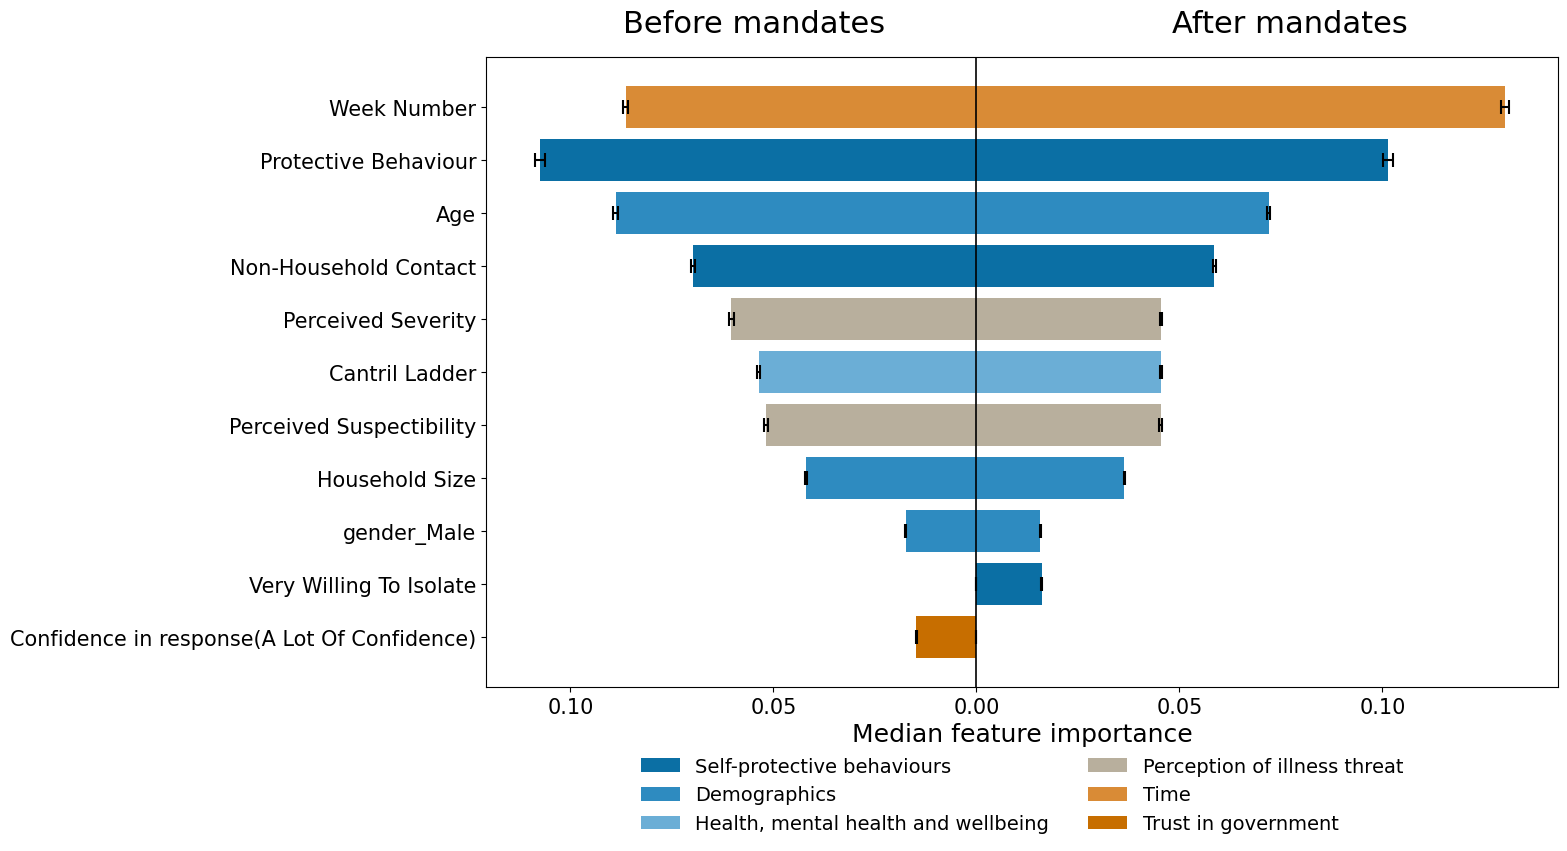

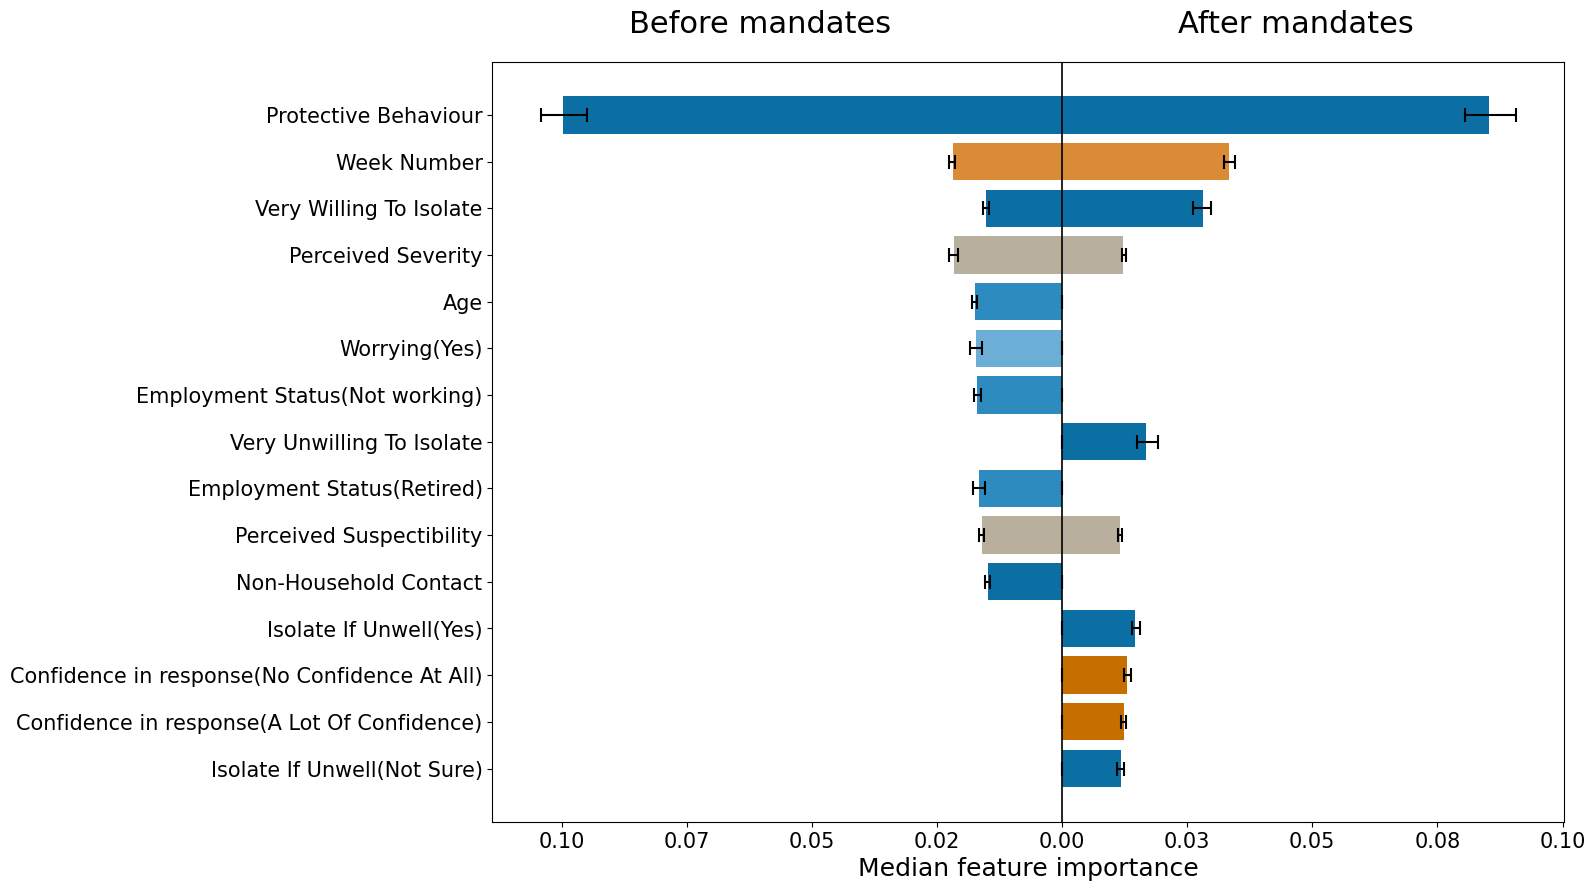

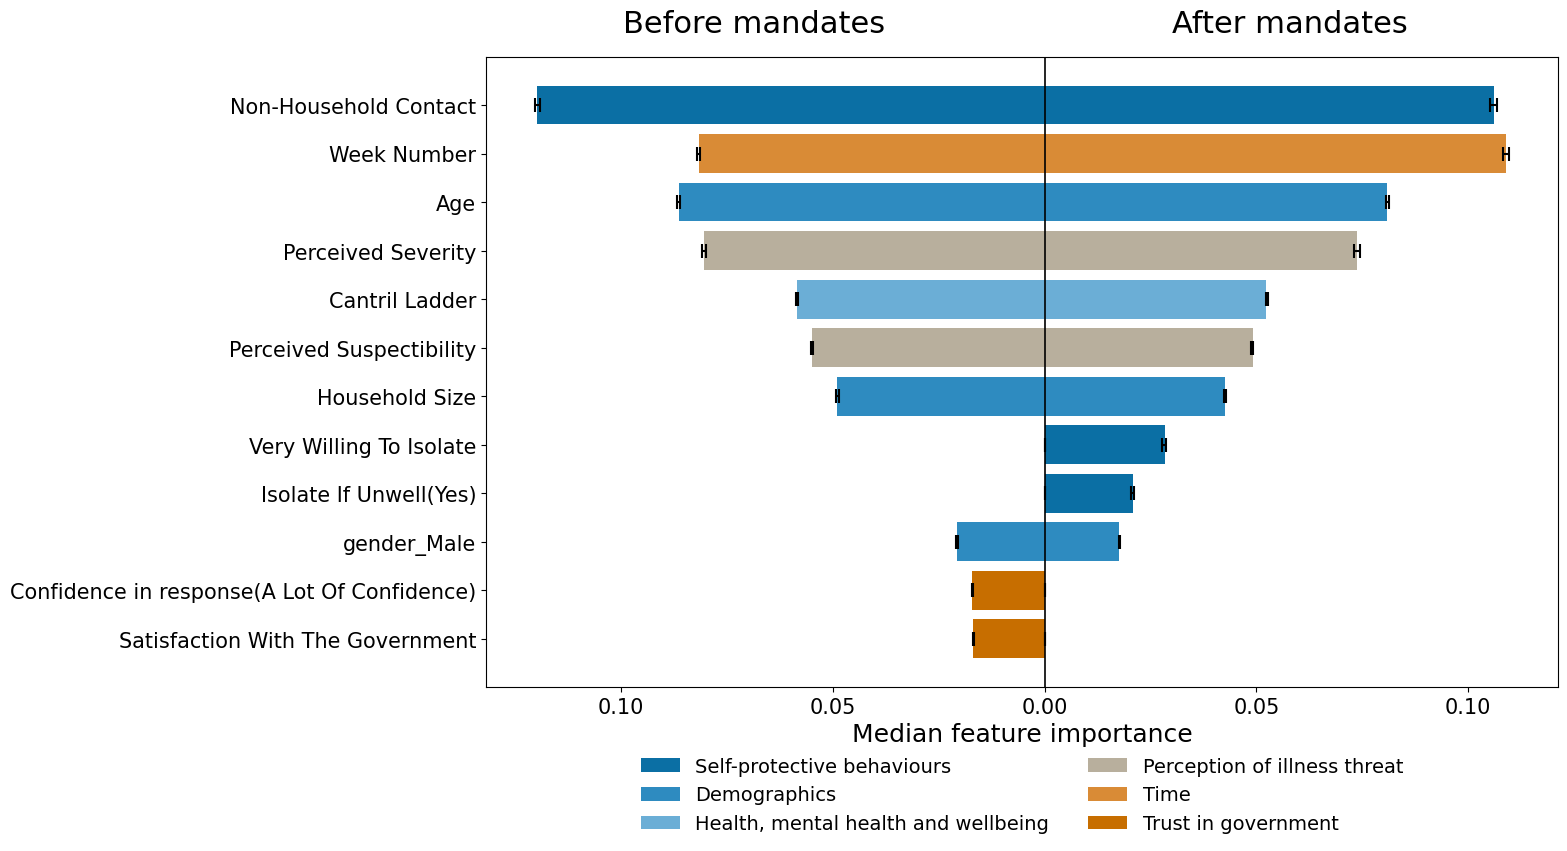

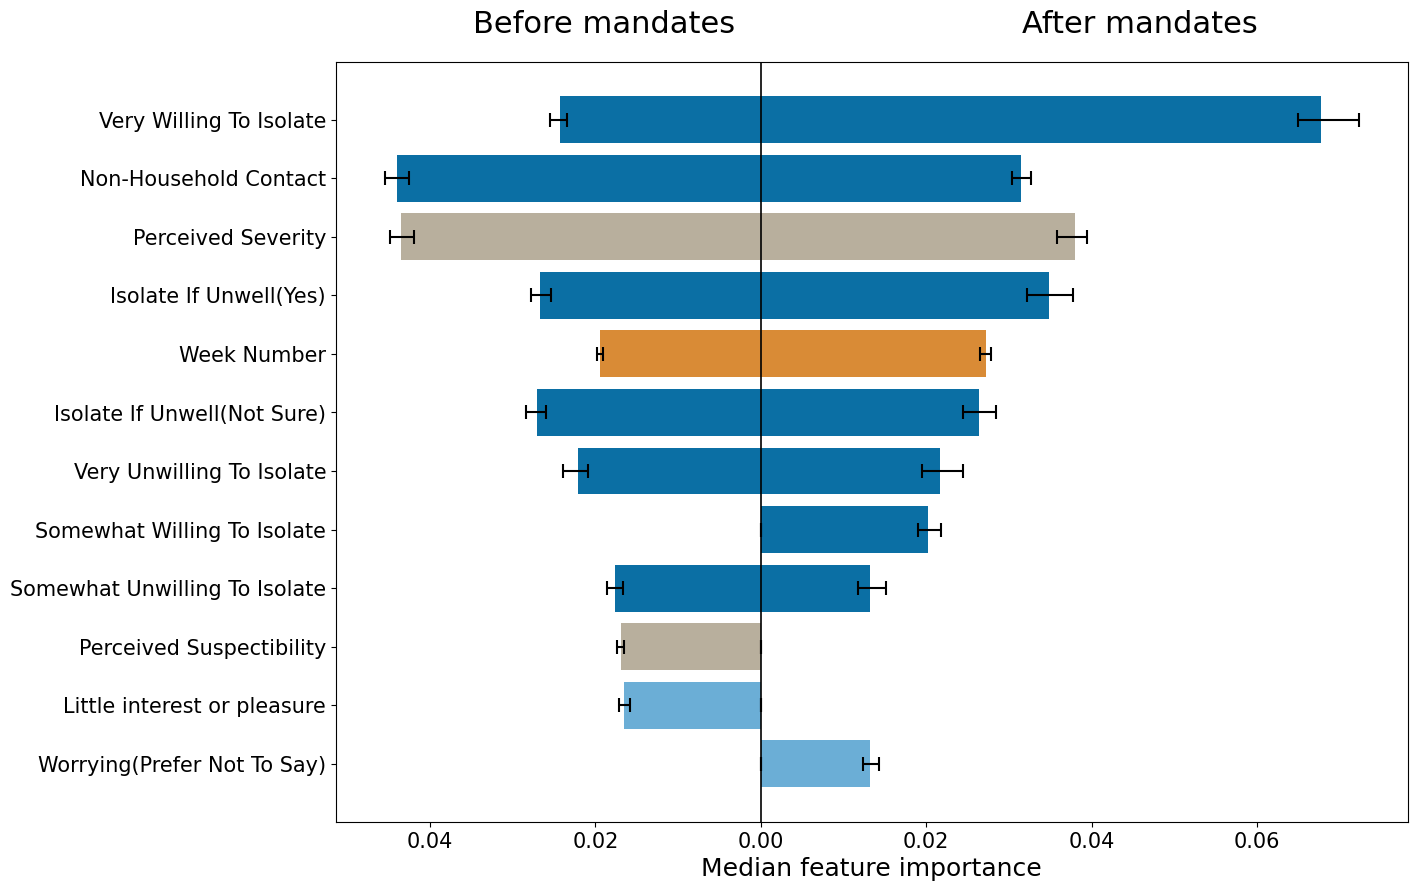

In [ ]:
# Cell 21
# Generate final mirrored feature importance figures
plot_mirrored_before_after_colored(
    mirror_rf_mask_labeled,
    output_path="Pictures/rf_mask_wearing_final.png",
    show_legend=True
)

plot_mirrored_before_after_colored(
    mirror_xgb_mask_labeled,
    output_path="Pictures/xgb_mask_wearing_final.png",
    show_legend=False
)

plot_mirrored_before_after_colored(
    mirror_rf_general_labeled,
    output_path="Pictures/rf_general_behaviour_final.png",
    show_legend=True
)

plot_mirrored_before_after_colored(
    mirror_xgb_general_labeled,
    output_path="Pictures/xgb_general_behaviour_final.png",
    show_legend=False
)

In [ ]:
# Cell 22
# Mirrored tables
mirror_rf_mask
mirror_xgb_mask
mirror_rf_general
mirror_xgb_general

,feature,median_importance_before,q1_before,q3_before,median_importance_after,q1_after,q3_after,max_importance
0,d1_comorbidities_Prefer_not_to_say,0.000000,0.000000,0.000000,0.013227,0.012305,0.014291,0.013227
1,PHQ4_1_Nearly every day,0.016514,0.015851,0.017165,0.000000,0.000000,0.000000,0.016514
2,r1_2,0.016970,0.016505,0.017386,0.000000,0.000000,0.000000,0.016970
3,i11_health_Somewhat unwilling,0.017686,0.016670,0.018582,0.013184,0.011691,0.015167,0.017686
4,i11_health_Somewhat willing,0.000000,0.000000,0.000000,0.020221,0.018984,0.021735,0.020221
5,i11_health_Very unwilling,0.022115,0.020878,0.023881,0.021649,0.019522,0.024407,0.022115
6,i9_health_Not sure,0.027049,0.025950,0.028406,0.026337,0.024417,0.028460,0.027049
7,week_number,0.019497,0.019133,0.019786,0.027243,0.026540,0.027840,0.027243
8,i9_health_Yes,0.026689,0.025332,0.027801,0.034784,0.032209,0.037757,0.034784
9,r1_1,0.043503,0.041943,0.044894,0.037951,0.035802,0.039461,0.043503
